# <span style='color: red;'>Pauli twirling</span>

## 1. What is Pauli twirling?
Pauli twirling is a noise tailoring technique that converts complex **coherent noise** (systematic rotations) into simpler **stochastic Pauli noise** (probabilistic flips).

In real hardware, errors are often coherent. This means they behave like small unwanted unitary rotations. These errors accumulate constructively and can distort results in a structured, hard-to-predict way.

**How it works:**

Pauli twirling mathematically "massages" this noise by randomly inserting Pauli gates before and after operations.
* We sandwich a noisy gate between a random Pauli $P$ and its correction $P^\dagger$.
* The logical operation remains unchanged ($P^\dagger P = I$).
* However, the noise gets averaged over many runs.

**The Result:**

Instead of a small, unknown rotation angle $\theta$, the channel behaves like a simple probabilistic mixture:
* With probability $p_X$: an X error (bit flip)
* With probability $p_Y$: an Y error (phase-bit flip)
* With probability $p_Z$: an Z error (phase flip)

Two key properties worth explicitly stating:
* It does not change the average gate fidelity
* It removes coherent errors by converting them into stochastic Pauli errors

This makes the error profile **diagonal** in the Pauli basis, which is much easier to analyze and mitigate using Quantum Error Correction (QEC).

## 2. Pauli twirling - the mathematics
Let $\mathcal{E}$ be a quantum channel acting on density matrices. The Pauli twirling of $\mathcal{E}$ is defined as:
$$
    \mathcal{E}_\text{twirled}(\rho) = \frac{1}{4^n} \sum_{P\in \mathcal{P}_n}P^\dagger \mathcal{E}(P\rho P^\dagger)P
$$
where the summation run over the $4^n$ Pauli operations in $\mathcal{P}_n = \{ I,X,Y,Z \}^{\otimes n}$

This operation averages the noise over conjugations by Pauli operators. The resulting channel eliminates the off-diagonal terms of the error process, leaving only a weighted sum of Pauli errors:
$$
    \mathcal{E}_\text{twirled}(\rho) = (1-p) \rho + p_x X\rho X + p_y Y\rho Y + p_z Z\rho Z
$$

## 3. Practical use case in Qiskit
We will now demonstrate this effect.
1. **Base Circuit:** Create a clean Bell state.
2. **Coherent Noise:** Apply a small unitary rotation error (Statevector visualization).
3. **Twirling:** Manually average this error over the Pauli group to see it become stochastic (Density Matrix visualization).

#### Prerequisites:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, DensityMatrix, Operator, Pauli
from qiskit.visualization import plot_bloch_multivector

### Step 1: Base circuit
We start with a standard Bell state preparation.

Base circuit (Bell state):


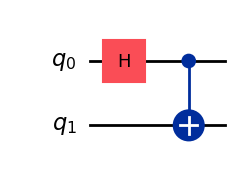

Ideal State:


<IPython.core.display.Latex object>

In [ ]:
# Create base circuit - Bell state
qc = QuantumCircuit(2)

# Add H and CNOT
qc.h(0)
qc.cx(0, 1)

# Draw base circuit
print("Base circuit (Bell state):")
display(qc.draw('mpl'))

# Ideal Statevector
sv_ideal = Statevector(qc)
print("Ideal State:")
display(sv_ideal.draw('latex'))

---

### Step 2: Adding Coherent Noise (The Problem)

We simulate a systematic error. Imagine our hardware always over-rotates by a small angle $\epsilon$ around the Z-axis after the CNOT.

In [ ]:
# Define (noise) error through small angle rotation
epsilon = 0.2

# Create circuit of two qubits
noise_circ = QuantumCircuit(2)

# Rz(epsilon) on qubit 0
noise_circ.rz(epsilon, 0)

# This represents a single run where the error happens deterministically.
sv_noisy = sv_ideal.evolve(noise_circ)  # # Expand noise to 2 qubits (I on q1)

print(f"State with Coherent Error (Rotation by {epsilon}):")
display(sv_noisy.draw('latex'))

State with Coherent Error (Rotation by 0.2):


<IPython.core.display.Latex object>

_Note: In the LaTeX output above, you see complex amplitudes. The state is still pure, but it is rotated away from the ideal Bell state._

---

### Step 3: Applying Pauli Twirling (The Solution)
Now we apply the twirling formula. We cannot use `Statevector` here because twirling creates a **mixed state** (an ensemble average). We must switch to `DensityMatrix`.

We will use the `noise_circ` you created, convert it to an operator, and then perform the twirl.

In [ ]:
# 1. Start with the Ideal Density Matrix
rho_ideal = DensityMatrix(sv_ideal)

# 2. Define the single-qubit Pauli set {I, X, Y, Z} 
# We twirl qubit 0 because that is where the noise is located
paulis = [Pauli('I'), Pauli('X'), Pauli('Y'), Pauli('Z')]

# 3. Create the Operator from your working noise circuit
# This converts your Rz(epsilon) circuit into a mathematical matrix
noise_op = Operator(noise_circ)

# 4. Initialize an empty matrix for the sum
rho_twirled_data = np.zeros((4, 4), dtype=complex)

# 5. Perform the Twirl Loop
print("Applying Pauli Twirling on Qubit 0...")

for P in paulis:
    # Expand P to 2 qubits: P acts on q0, Identity acts on q1
    # Qiskit notation: Pauli('IP') means P on q0, I on q1
    P_2q = Pauli('I').expand(P) 
    
    # Calculate: P * rho_ideal * P_dagger
    rho_pre = rho_ideal.evolve(P_2q)
    
    # Apply the Noise Operator: Noise * rho_pre * Noise_dagger
    rho_noisy_instance = rho_pre.evolve(noise_op)
    
    # Apply Correction: P_dagger * rho_noisy * P
    rho_corrected = rho_noisy_instance.evolve(P_2q)
    
    # Add to the sum
    rho_twirled_data += rho_corrected.data

# 6. Normalize (average over the 4 Pauli gates)
rho_twirled = DensityMatrix(rho_twirled_data / 4)

print("Twirled Density Matrix computed successfully.")

Applying Pauli Twirling on Qubit 0...
Twirled Density Matrix computed successfully.


---

### Step 4: Comparing the Results
Let's compare the Coherent Noisy State (from Step 2) with the **Twirled State** (from Step 3).

We look at the "Fidelity" to the ideal state. Interestingly, twirling **does not change** the fidelity; it only changes the type of error.

In [ ]:
from qiskit.quantum_info import state_fidelity

# Convert Step 2 Statevector to DensityMatrix for comparison
rho_coherent = DensityMatrix(sv_noisy)

fid_coherent = state_fidelity(rho_ideal, rho_coherent)
fid_twirled = state_fidelity(rho_ideal, rho_twirled)

print(f"Fidelity (Coherent Noise): {fid_coherent:.5f}")
print(f"Fidelity (Twirled Noise):  {fid_twirled:.5f}")
print("\nNotice the fidelities are identical! Twirling simplifies noise, it doesn't remove it!")

Fidelity (Coherent Noise): 0.99003
Fidelity (Twirled Noise):  0.99003

Notice the fidelities are identical! Twirling simplifies noise, it doesn't remove it!


#### Visualizing the effect:

If we visualize the density matrices, we can see that the coherent error has off-diagonal terms (coherence), while the twirled state suppresses these, making the error profile "stochastic" (closer to a classical probability distribution).

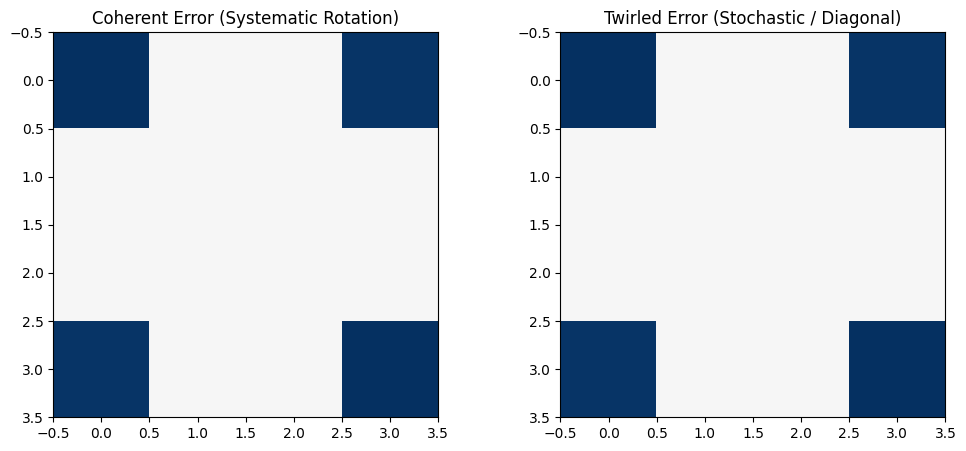

In [ ]:
# Visualization of the Density Matrices (Real parts)
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Plot Coherent Noise
axs[0].imshow(np.real(rho_coherent.data), cmap='RdBu', vmin=-0.5, vmax=0.5)
axs[0].set_title("Coherent Error (Systematic Rotation)")

# Plot Twirled Noise
axs[1].imshow(np.real(rho_twirled.data), cmap='RdBu', vmin=-0.5, vmax=0.5)
axs[1].set_title("Twirled Error (Stochastic / Diagonal)")

plt.show()